### Import bibliotek i konfiguracja

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
)

RANDOM_STATE = 1
np.random.seed(RANDOM_STATE)

ADOPTION_SPEED_LABELS = {
    0: '0–7',
    1: '8–30',
    2: '31–90',
    3: '>100',
}
CLASS_ORDER = sorted(ADOPTION_SPEED_LABELS.keys())
CLASS_NAMES = [ADOPTION_SPEED_LABELS[c] for c in CLASS_ORDER]

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### Wczytanie i przygotowanie danych

In [2]:
PROCESSED_DIR = '../data/processed'
MODELS_DIR = Path('../models')
INPUT_PATH = f'{PROCESSED_DIR}/train_clean_anomaly.csv'

df = pd.read_csv(INPUT_PATH)

# Nie dodajemy do modelu rekordów-anomalii
if 'is_anomaly' in df.columns:
    df = df.drop(columns=['is_anomaly'])

y = df['AdoptionSpeed']
X = df.drop(columns=['AdoptionSpeed'])
feature_names = X.columns.tolist()

print('Rozkład klas AdoptionSpeed (%):')
class_dist = pd.DataFrame({
    'liczba': y.value_counts().sort_index(),
    'procent': (y.value_counts(normalize=True).sort_index() * 100).round(2),
})
class_dist.index.name = 'AdoptionSpeed'
display(class_dist)

# Podział zachowuje proporcje klas
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Skalowanie 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nX_train: {X_train_scaled.shape}, y_train: {y_train.shape}')
print(f'X_test:  {X_test_scaled.shape}, y_test:  {y_test.shape}')

Rozkład klas AdoptionSpeed (%):


,liczba,procent
AdoptionSpeed,,
0,3474,23.40
1,3993,26.90
2,3209,21.62
3,4168,28.08



X_train: (11875, 20), y_train: (11875,)
X_test:  (2969, 20), y_test:  (2969,)


### SVM

Classification report (base SVM)
              precision    recall  f1-score   support

         0–7       0.36      0.34      0.35       695
        8–30       0.33      0.41      0.36       798
       31–90       0.40      0.14      0.21       642
        >100       0.47      0.60      0.53       834

    accuracy                           0.39      2969
   macro avg       0.39      0.37      0.36      2969
weighted avg       0.39      0.39      0.37      2969

Accuracy: 0.3907
F1 macro: 0.3626


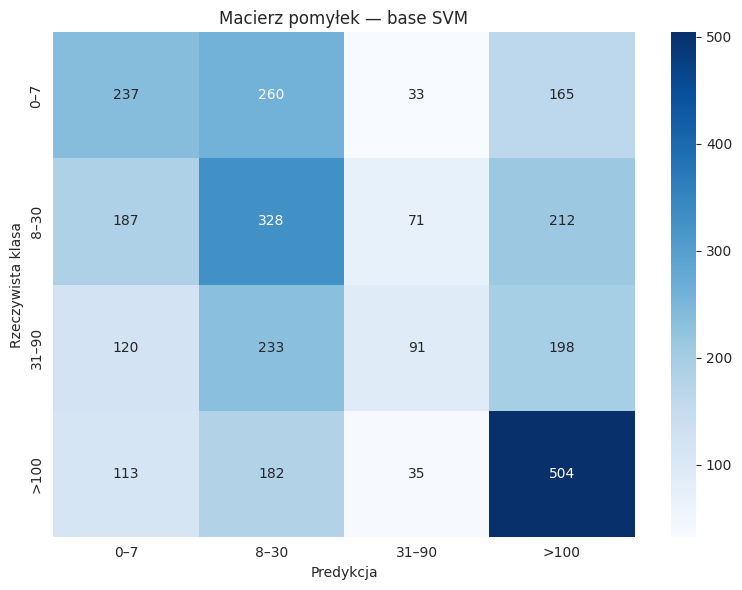

In [3]:
svm_base = SVC(random_state=RANDOM_STATE, probability=True)
svm_base.fit(X_train_scaled, y_train)

y_pred_base = svm_base.predict(X_test_scaled)

acc_base = accuracy_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base, average='macro')

print('Classification report (base SVM)')
print(classification_report(y_test, y_pred_base, target_names=CLASS_NAMES))
print(f'Accuracy: {acc_base:.4f}')
print(f'F1 macro: {f1_base:.4f}')

cm_base = confusion_matrix(y_test, y_pred_base, labels=CLASS_ORDER)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_base,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title('Macierz pomyłek — base SVM')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywista klasa')
plt.tight_layout()
plt.show()

### Cross-validation

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    SVC(random_state=RANDOM_STATE),
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='accuracy',
)

print('Wyniki accuracy dla poszczególnych powtórzeń:')
for i, score in enumerate(cv_scores, start=1):
    print(f'  Powtórzenie {i}: {score:.4f}')

print(f'\nŚrednia: {cv_scores.mean():.4f}')
print(f'Odchylenie std: {cv_scores.std():.4f}')
print(f'Zakres (średnia ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Wyniki accuracy dla poszczególnych powtórzeń:
  Powtórzenie 1: 0.3857
  Powtórzenie 2: 0.3891
  Powtórzenie 3: 0.3819
  Powtórzenie 4: 0.3874
  Powtórzenie 5: 0.3924

Średnia: 0.3873
Odchylenie std: 0.0035
Zakres (średnia ± std): 0.3873 ± 0.0035


### Kalibracja

Najlepsze parametry:
{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

Najlepszy wynik CV (accuracy): 0.3933

Porównanie na zbiorze testowym:


,accuracy,f1_macro
base,0.390704,0.362618
po GridSearchCV,0.390704,0.362618


Classification report (po kalibracji)
              precision    recall  f1-score   support

         0–7       0.36      0.34      0.35       695
        8–30       0.33      0.41      0.36       798
       31–90       0.40      0.14      0.21       642
        >100       0.47      0.60      0.53       834

    accuracy                           0.39      2969
   macro avg       0.39      0.37      0.36      2969
weighted avg       0.39      0.39      0.37      2969



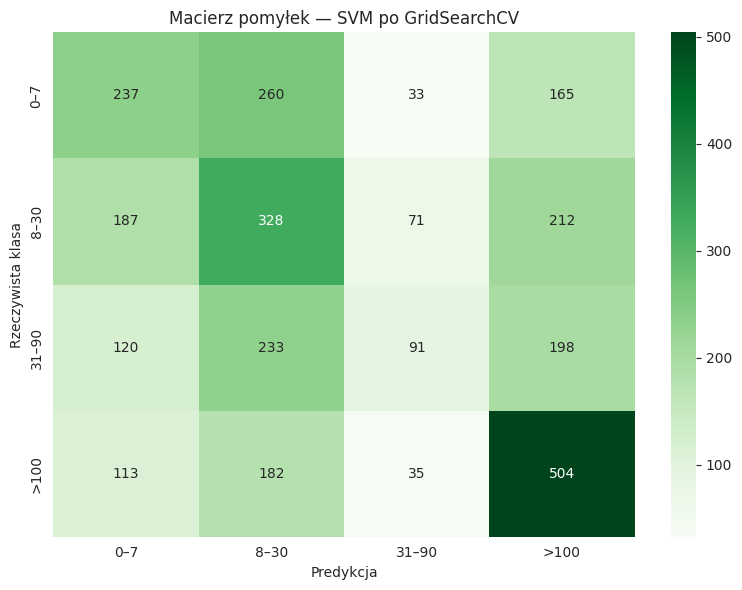

In [6]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto'],
}

grid_search = GridSearchCV(
    estimator=SVC(random_state=RANDOM_STATE, probability=True),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
)

grid_search.fit(X_train_scaled, y_train)

print('Najlepsze parametry:')
print(grid_search.best_params_)
print(f'\nNajlepszy wynik CV (accuracy): {grid_search.best_score_:.4f}')

svm_best = grid_search.best_estimator_
y_pred_tuned = svm_best.predict(X_test_scaled)

acc_tuned = accuracy_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned, average='macro')

comparison = pd.DataFrame({
    'accuracy': [acc_base, acc_tuned],
    'f1_macro': [f1_base, f1_tuned],
}, index=['base', 'po GridSearchCV'])

print('\nPorównanie na zbiorze testowym:')
display(comparison)

print('Classification report (po kalibracji)')
print(classification_report(y_test, y_pred_tuned, target_names=CLASS_NAMES))

cm_tuned = confusion_matrix(y_test, y_pred_tuned, labels=CLASS_ORDER)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title('Macierz pomyłek — SVM po GridSearchCV')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywista klasa')
plt.tight_layout()
plt.show()

### Zapis modelu